# Sentiment Analysis

In this notebook we use an RNN network to classify text. The text we will use are IMDB movie reviews and the classification is either positive (1) or negative (0). We employ several different techniques from our other models
* The input lengths vary and there are no windows -- the input is the entire review. This will require the use of "padding" tokens to keep the data stored in a matrix
* The input words are encoded to integers using a tensorflow text vectorization layer.
* These vectors are embedded in a high dimensional vector space using an embedding layer
* We also show how to use a pretrained embedding layer in your model (requires access to kaggle)
* The model data is stored as a tensorflow dataset, which allows shuffling, batchig and caching to optimize training time.

In [ ]:
# Sentiment Analysis

In [2]:
%pip install tensorflow-datasets

  Preparing metadata (setup.py) ... done
  Using cached zipp-3.21.0-py3-none-any.whl.metadata (3.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 4.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 4.9 MB/s eta 0:00:0000:0100:01
Using cached zipp-3.21.0-py3-none-any.whl (9.6 kB)
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21484 sha256=038805388768675e0f2d9221e1ef6e82eca786653e82d94068fe7a09ce791aec
  Stored in directory: /home/arush/.cache/pip/wheels/90/74/b1/9b54c896b8d9409e9268329d4d45ede8a8040abe91c8879932
Successfully built promise

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow_datasets as tfds
import tensorflow as tf

2025-03-20 14:39:44.857821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742495985.032595   73475 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742495985.062730   73475 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Load the data from tensorflow's own database

In [4]:
raw_train, raw_validation, raw_test = tfds.load(
    name="imdb_reviews",
    split=['train', 'test', 'test'],
    as_supervised=True
)

/home/arush/ML/tf-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 100%|██████████| 1/1 [00:22<00:00, 22.72s/ url]


Dataset imdb_reviews downloaded and prepared to /home/arush/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


I0000 00:00:1742496069.033942   73475 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2256 MB memory:  -> device: 0, name: NVIDIA T500, pci bus id: 0000:01:00.0, compute capability: 7.5


Create datasets that use shuffling, batching and prefetching. (Change the batchsize here if you want)

In [5]:
tf.random.set_seed(42)
train_set = raw_train.shuffle(5000, seed=42).batch(32).prefetch(1)
valid_set = raw_validation.batch(32).prefetch(1)
test_set = raw_test.batch(32).prefetch(1)

Show some of the raw data. Notice the use of `take` to extract data from a tf.dataset

In [6]:
for review, label in raw_train.take(10):
    print(review.numpy().decode("utf-8")) # decode converts a python byte array to correct text
    print(label.numpy())

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
0
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot development was co

Do some EDA on the dataset. Also note how we access and iterate through the raw data

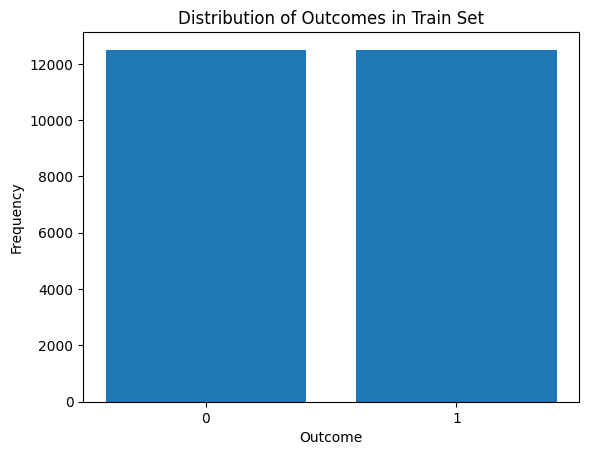

In [7]:
import matplotlib.pyplot as plt

# Assuming 'train_set' is a tf.data.Dataset with labels (0 or 1)
label_list = []
for _, label in raw_train:
  label_list.append(label.numpy())

plt.hist(label_list, bins=[0, 0.5, 1], rwidth=0.8)
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.title("Distribution of Outcomes in Train Set")
plt.xticks([0.25, 0.75], ["0", "1"])
plt.show()


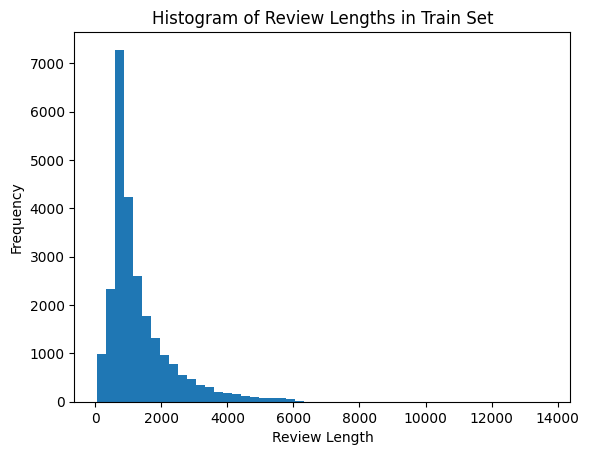

In [8]:
review_lengths = []
for review, _ in raw_train:
  review_lengths.append(len(review.numpy()))

plt.hist(review_lengths, bins=50)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Histogram of Review Lengths in Train Set")
plt.show()


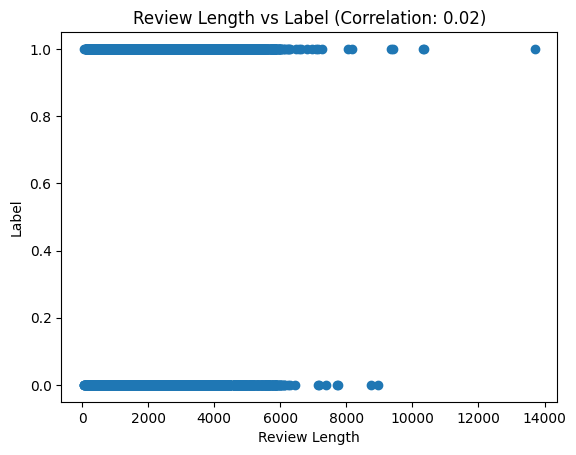

Correlation between review length and label: 0.02


In [10]:
import numpy as np

review_lengths = []
labels = []
for review, label in raw_train:
  review_lengths.append(len(review.numpy()))
  labels.append(label.numpy())

# Calculate correlation
correlation = np.corrcoef(review_lengths, labels)[0, 1]

# Plot review length vs label
plt.scatter(review_lengths, labels)
plt.xlabel("Review Length")
plt.ylabel("Label")
plt.title(f"Review Length vs Label (Correlation: {correlation:.2f})")
plt.show()

print(f"Correlation between review length and label: {correlation:.2f}")


As we have done before using scikit-learn (or manual code), we convert the top 1000 most common vocab terms in the dataset to integers. We will use a tensorflow TextVectorization layer to do so. The layer will take some time to train because of the size of the data. Therefore we show how to save the layer as a tensorflow model for extraction later. Set the 'false' below to 'true' to generate the layer. Be sure to update the filepath and mount Google Drive.

In [ ]:
if True:
  vocab_size = 1000
  text_vec_layer = tf.keras.layers.TextVectorization(
      max_tokens=vocab_size,
      output_mode="int",
  )
  text_vec_layer.adapt(raw_train.map(lambda review, label: review))
    # Create model to save TextVectorization Layer
  model = tf.keras.models.Sequential()
  model.add(tf.keras.Input(shape=(1,), dtype=tf.string))
  model.add(text_vec_layer)

  # Save.
  filepath = "/content/drive/MyDrive/Colab Notebooks/TextVecLayer-IMBD.keras"
  filepath = "./TextVecLayer-IMBD.keras"
  model.save(filepath)

Adapting TextVectorization: 100%|██████████| 25000/25000 [00:00<00:00, 5723043.34it/s]


KeyboardInterrupt: 

Now load the layer (from above or an earlier session)

In [ ]:
filepath = "/content/drive/MyDrive/Colab/TextVecLayer-IMBD.keras"
loaded_model = tf.keras.models.load_model(filepath)
text_vec_layer = loaded_model.layers[0]

Let's see how this layer works

In [ ]:
text_vec_layer.vocabulary_size()

In [ ]:
text_vec_layer.get_vocabulary()[:20]

Token #1 is UNK, for unknown words (not in the top 1000 vocab). Token 0 is empty space used for padding.

In [ ]:
text_vec_layer(["you", 'saw', 'the', 'armadillo', '', ''])

Now create the model. Use the vector layer and an embedding layer. Then a simple GRU stack and a single neuron to classify. Note the use of sigmoid since the output data is a single [0,1] variable.

In [ ]:
import os, datetime

embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)

### Task

*TO DO*. Run the model on some testing data and print a few of the samples it misclassifies. Read the samples yourself -- do you see why they were misclassified?

In [ ]:
### Your Code HERE

# Pretrained Encoding Layers

We show how to load a pretrained sentence encoding layer. There were some complications here getting this to run so there are some hacky fixes. Also note the url hard-links to kaggle, so you need to access that to get the model. Currently this example does not get better accuracy than above in 5 epochs. Consider it a work in progress.

In any case, this model trained on millions of text documents encodes entire sentences into one vector.

In [ ]:
import os
import tensorflow_hub as hub

os.environ["TFHUB_CACHE_DIR"] = "/content/drive/MyDrive/Colab/Cache"

encoder_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4", trainable=True, dtype=tf.string, input_shape=[])

In [ ]:
encoder_layer(["I don't think you enjoy the company of cats"])

In [ ]:
import os, datetime

embed_size = 128
tf.random.set_seed(42)
encoder_layer_wrapped = tf.keras.layers.Lambda(lambda x: encoder_layer(x))

model = tf.keras.Sequential([
    encoder_layer_wrapped,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])


tf.config.optimizer.set_jit(False)


history = model.fit(train_set, validation_data=valid_set, epochs=5, callbacks=[tensorboard_callback])

### Task

Classify another text corpus -- I suggest the Amazon Review dataset. This is a 1-5 rating so you will probably want to one-hot encode the classifications. You could re-use the TextVectorization layer above or train a new one. If you want you can also use a pretrained model and see how it does.

In [13]:
import json
import pandas as pd
import os
from tqdm import tqdm
import pickle
import tensorflow as tf
import tensorflow_hub as hub
import datetime
from sklearn.model_selection import train_test_split

In [2]:
def get_data(firstTime = False):
    if firstTime or not os.path.exists('data/Boxreviews.pkl'):
        header = ['title', 'text', 'rating']
        df = pd.DataFrame(columns=header)
        with open('data/Subscription_Boxes.jsonl', 'r') as input_file:
            for line in tqdm(input_file, total=16216):
                review = json.loads(line)
                df.loc[len(df)] = [review['title'], review['text'], review['rating']]
            pickle.dump(df, open('data/Boxreviews.pkl', 'wb'))
            return df
    return pickle.load(open('data/Boxreviews.pkl', 'rb'))

In [26]:
def preprocess_data(df):
    df = pd.get_dummies(df, columns=['rating'], dtype='int')
    return df

In [27]:
df = get_data()
df = preprocess_data(df)
df

,title,text,rating_1.0,rating_2.0,rating_3.0,rating_4.0,rating_5.0
0,USELESS,Absolutely useless nonsense and a complete was...,1,0,0,0,0
1,Manufactured where?,"With a couple of the items, I wasn't quite sur...",0,1,0,0,0
2,Little bang for your buck.,Two SMALL stuffed animals and 2 little bags of...,1,0,0,0,0
3,New favorite box,"Although I don’t remember signing up for this,...",0,0,0,0,1
4,Coctique,I loved every thing and could use it all. Thin...,0,0,0,0,1
...,...,...,...,...,...,...,...
16211,Very pleased,My husband loved it and look forward to seeing...,0,0,0,0,1
16212,??????,Y’all can do so much better. One pop one mini?...,1,0,0,0,0
16213,Always a great surprise inside,I’ve been a member for a few years now and I’v...,0,0,0,0,1
16214,"If you’re looking for a box, you have the wron...",First few boxes were great. Higher value items...,1,0,0,0,0


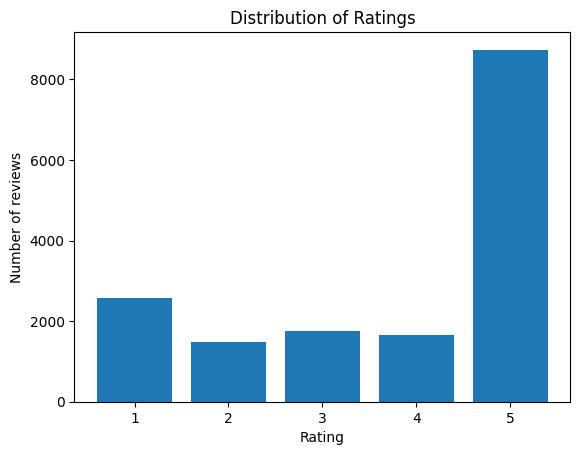

In [28]:
import matplotlib.pyplot as plt
rating_counts = [len(df[df[f'rating_{i+1}.0'] == 1]) for i in range(5)]
plt.bar(range(1, 6), rating_counts)
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Distribution of Ratings")
plt.show()

It looks like most people were happy with their subscription boxes. I'll downsample the reviews to make the dataset balanced, and also easier to work with.

In [29]:
# trim the dataframe to have equal number of reviews for each rating
min_rating = min(rating_counts)
df = pd.concat([df[df[f'rating_{i+1}.0'] == 1].sample(min_rating) for i in range(5)])

I'll be using the pretrained encoding layer to transform the text, instead of training a new one.

In [30]:
os.environ["TFHUB_CACHE_DIR"] = "data/cache"

encoder_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4", trainable=True, dtype=tf.string, input_shape=[])

In [31]:
encoder_layer(["I don't think you enjoy the company of cats"]);

In [32]:
X = df['text'].values
y = df.iloc[:, 2:].values
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.2, random_state=42)

In [38]:
X_train.shape

(4771,)

In [ ]:
embed_size = 128
tf.random.set_seed(42)
encoder_layer_wrapped = tf.keras.layers.Lambda(lambda x: encoder_layer(x))

model = tf.keras.Sequential([
    encoder_layer_wrapped,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(5, activation="softmax")
])

logdir = os.path.join("data/logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

model.compile(loss="categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])


tf.config.optimizer.set_jit(False)


history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, callbacks=[tensorboard_callback])

Epoch 1/5


RuntimeError: pybind11::error_already_set: MISMATCH of original and normalized active exception types: ORIGINAL InvalidArgumentError REPLACED BY KeyboardInterrupt: <EMPTY MESSAGE>

At:
  /home/arush/ML/tf-env/lib/python3.11/site-packages/tensorflow/python/framework/errors_impl.py(284): __init__
  /home/arush/ML/tf-env/lib/python3.11/site-packages/tensorflow/python/eager/execute.py(53): quick_execute
  /home/arush/ML/tf-env/lib/python3.11/site-packages/tensorflow/python/eager/context.py(1688): call_function
  /home/arush/ML/tf-env/lib/python3.11/site-packages/tensorflow/python/eager/polymorphic_function/atomic_function.py(251): call_flat
  /home/arush/ML/tf-env/lib/python3.11/site-packages/tensorflow/python/eager/polymorphic_function/atomic_function.py(216): call_preflattened
  /home/arush/ML/tf-env/lib/python3.11/site-packages/tensorflow/python/eager/polymorphic_function/concrete_function.py(1322): _call_flat
  /home/arush/ML/tf-env/lib/python3.11/site-packages/tensorflow/python/eager/

: 